In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('./data/heart.csv')

In [8]:
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
# Check for null values
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [10]:
# Check data types
print("\nData types:")
print(df.dtypes)


Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [11]:
# Check target variable distribution
print("\nTarget variable distribution:")
print(df['HeartDisease'].value_counts())


Target variable distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


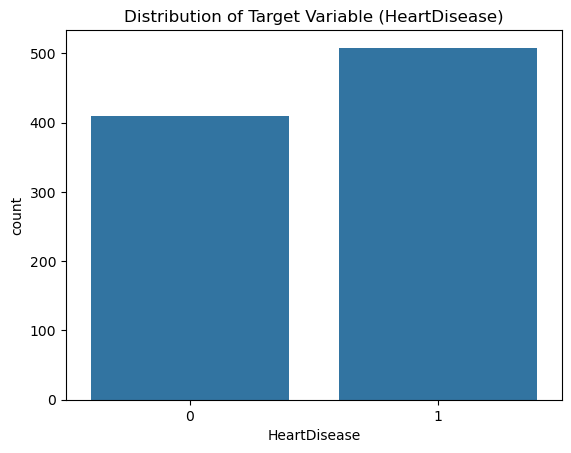

In [12]:
# Plot class distribution
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Target Variable (HeartDisease)")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# Step 1: One-hot encode categorical features (if any)
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
# Step 2: Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [16]:
# Step 3: Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Step 4: Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 734
Testing samples: 184


In [18]:
# Step 1: Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
# Step 2: Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)
# Step 3: Train the model
model.fit(X_train, y_train)
# Step 4: Make predictions on the test set
y_pred = model.predict(X_test)
# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8858695652173914

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



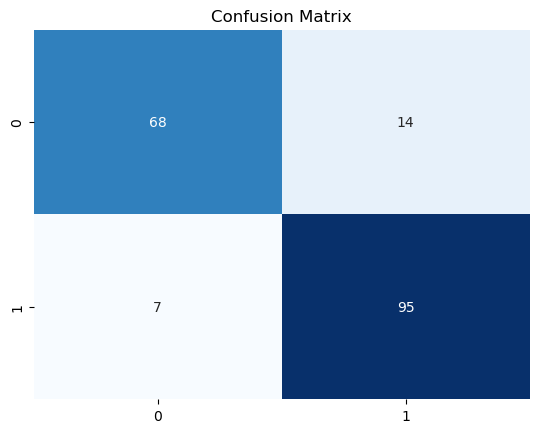

In [23]:
# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.show()

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [35]:
# Step 1: Define the Neural Network architecture with Dropout
model_nn = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.5),  # Adding Dropout layer to prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.5),  # Adding another Dropout layer
    Dense(1, activation='sigmoid')
])

In [36]:
# Step 2: Compile the model
model_nn.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy', AUC()])

In [37]:
# Step 3: Implement Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [38]:
# Step 4: Train the model with Early Stopping
history = model_nn.fit(X_train, y_train, epochs=20, batch_size=32, 
                       validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/20
23/23 [==============================] - 3s 40ms/step - loss: 0.7496 - accuracy: 0.5531 - auc_1: 0.5744 - val_loss: 0.6212 - val_accuracy: 0.7337 - val_auc_1: 0.8514
Epoch 2/20
23/23 [==============================] - 0s 10ms/step - loss: 0.6721 - accuracy: 0.6144 - auc_1: 0.6634 - val_loss: 0.5731 - val_accuracy: 0.8261 - val_auc_1: 0.9002
Epoch 3/20
23/23 [==============================] - 0s 10ms/step - loss: 0.6185 - accuracy: 0.6594 - auc_1: 0.7202 - val_loss: 0.5284 - val_accuracy: 0.8315 - val_auc_1: 0.9177
Epoch 4/20
23/23 [==============================] - 0s 17ms/step - loss: 0.5924 - accuracy: 0.7112 - auc_1: 0.7671 - val_loss: 0.4942 - val_accuracy: 0.8533 - val_auc_1: 0.9287
Epoch 5/20
23/23 [==============================] - 0s 10ms/step - loss: 0.5707 - accuracy: 0.7316 - auc_1: 0.7807 - val_loss: 0.4615 - val_accuracy: 0.8750 - val_auc_1: 0.9327
Epoch 6/20
23/23 [==============================] - 0s 11ms/step - loss: 0.5527 - accuracy: 0.7221 - auc_1: 0.7919 

In [39]:
# Step 5: Evaluate the model again
train_loss, train_accuracy, train_auc = model_nn.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy, test_auc = model_nn.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Training Accuracy: 0.8719
Test Accuracy: 0.8913
Test AUC: 0.9442


In [31]:
# Step 6: Plot Training History (Loss and Accuracy)
import matplotlib.pyplot as plt

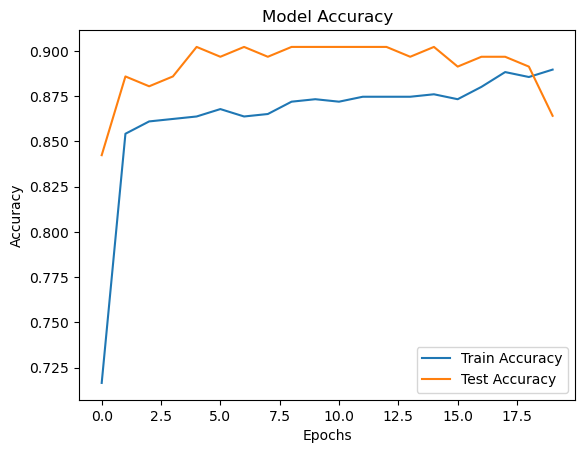

In [32]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

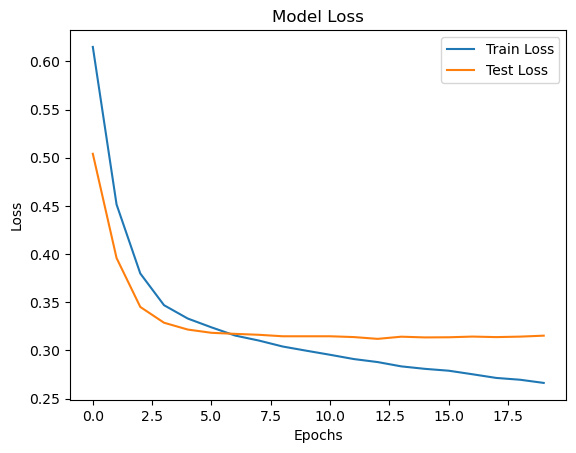

In [33]:
# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

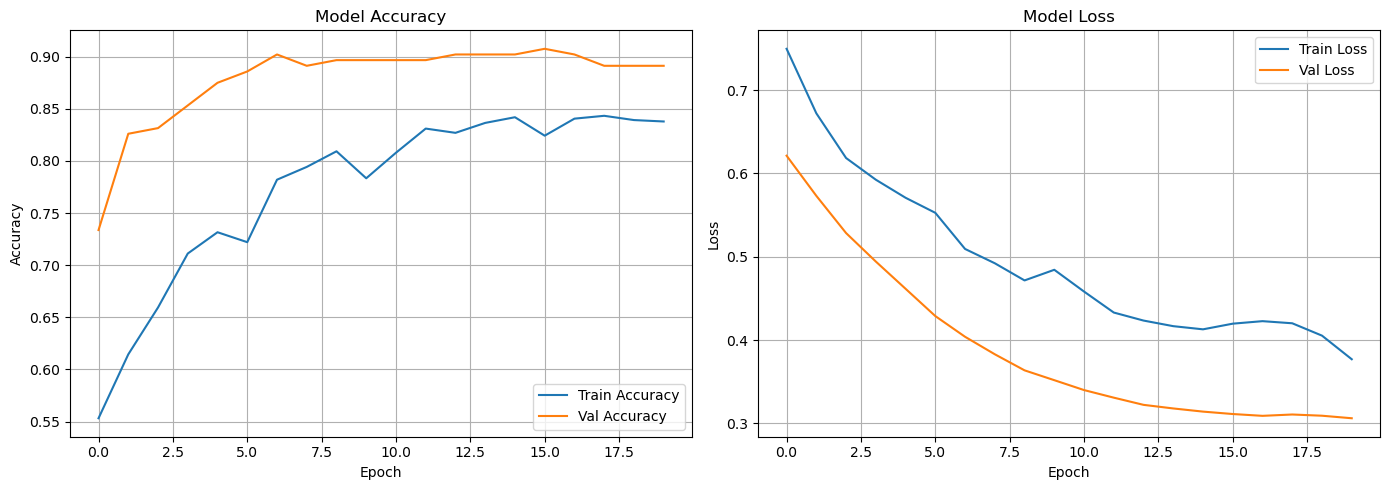

In [40]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


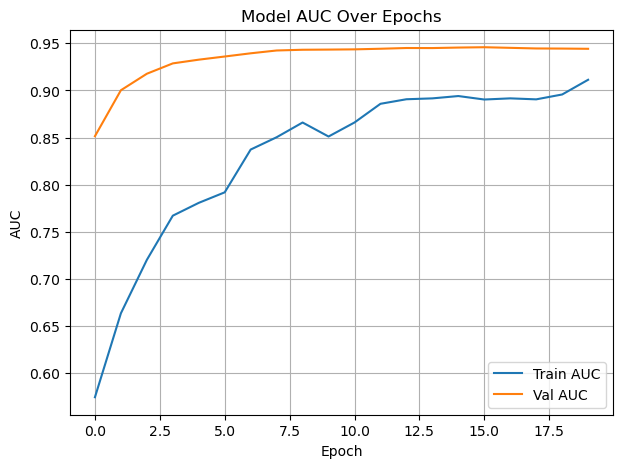

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['auc_1'], label='Train AUC')
plt.plot(history.history['val_auc_1'], label='Val AUC')
plt.title('Model AUC Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [42]:
plt.savefig('accuracy_vs_loss.png')

<Figure size 640x480 with 0 Axes>

Confusion Matrix:
[[68 14]
 [ 7 95]]


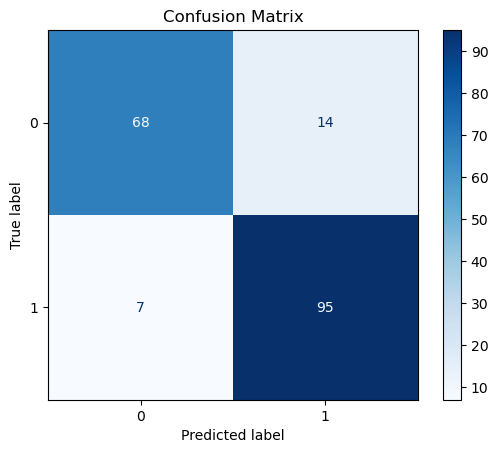


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


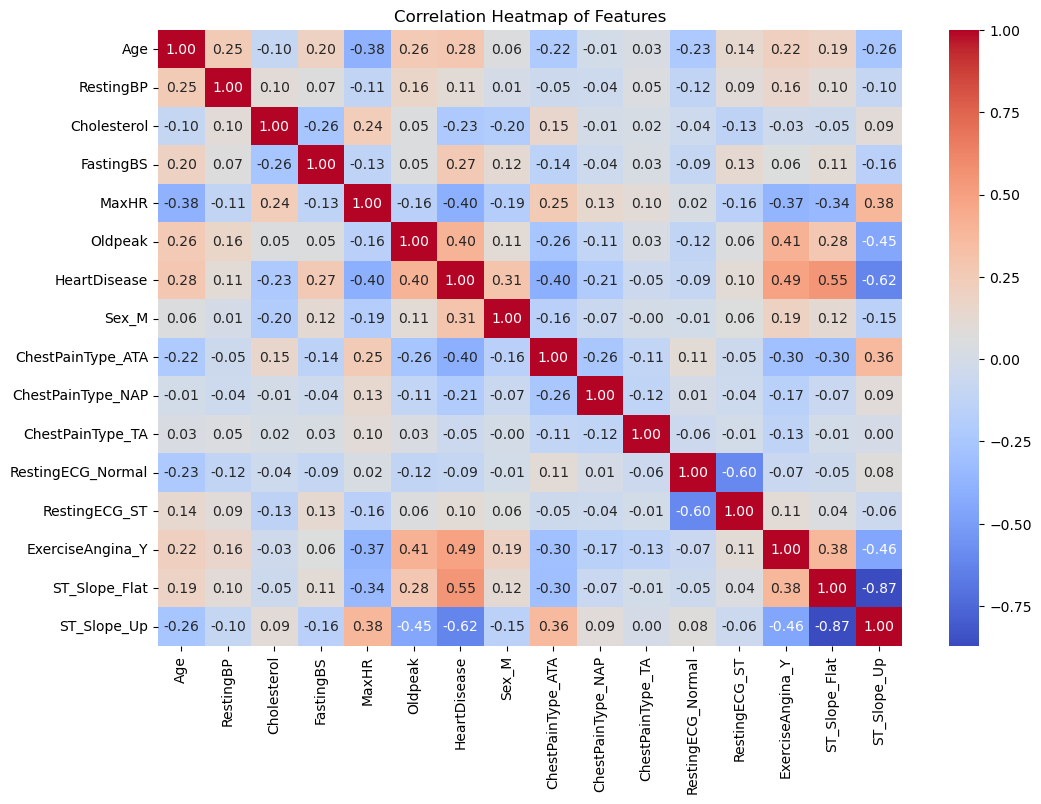

In [44]:
# Convert categorical columns to numeric (optional for heatmap)
df_encoded = pd.get_dummies(df, drop_first=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

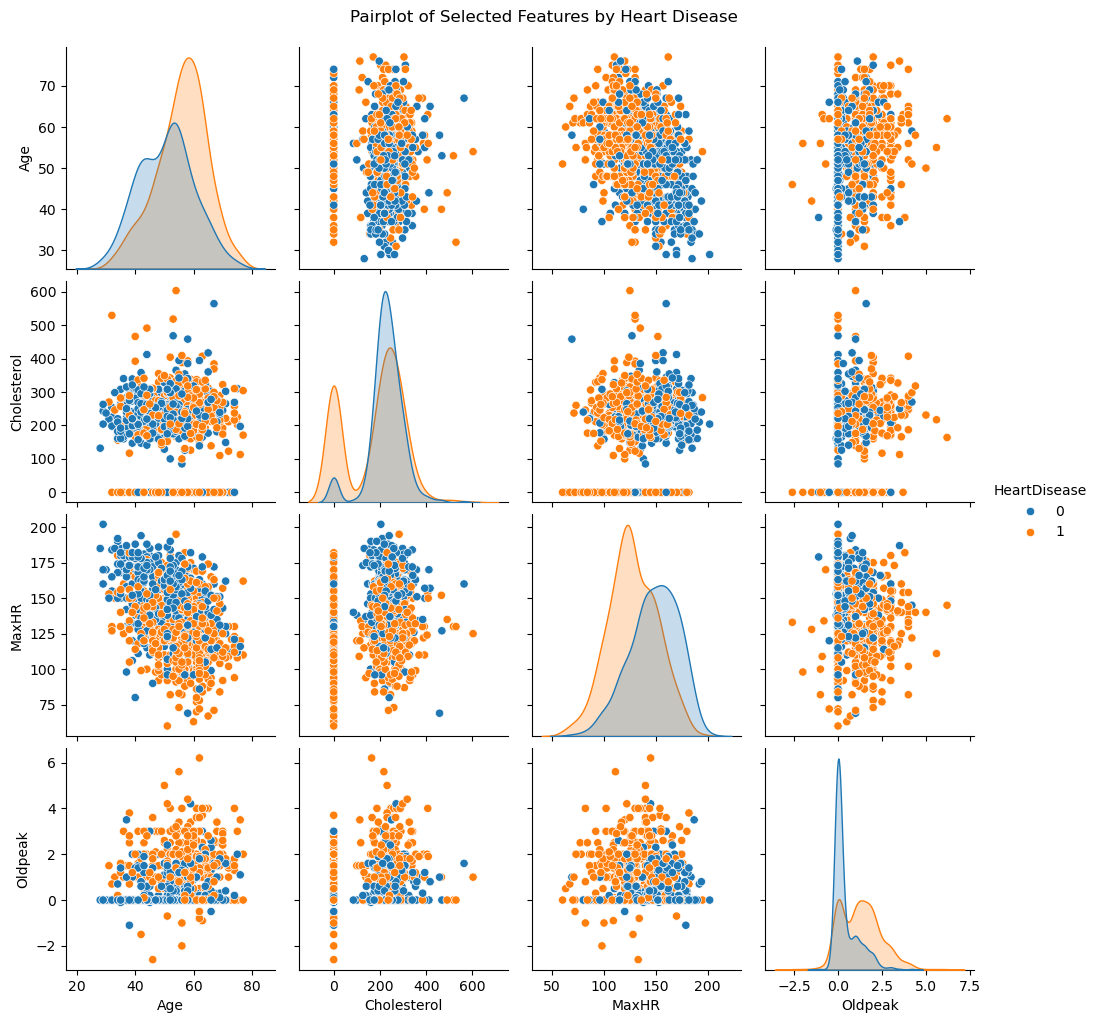

In [45]:
sns.pairplot(df, hue="HeartDisease", vars=["Age", "Cholesterol", "MaxHR", "Oldpeak"])
plt.suptitle("Pairplot of Selected Features by Heart Disease", y=1.02)
plt.show()


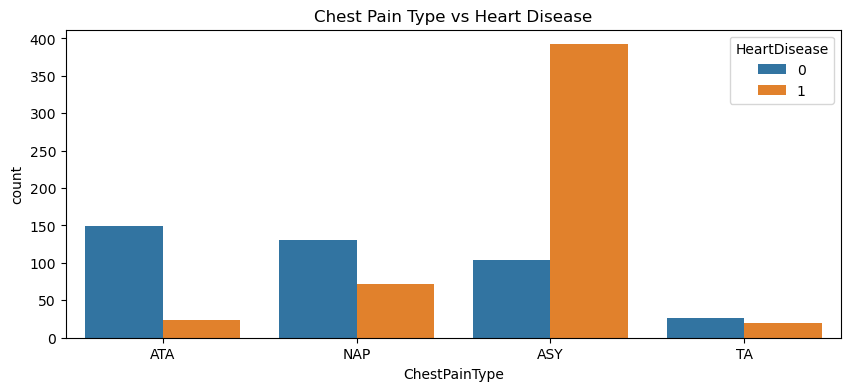

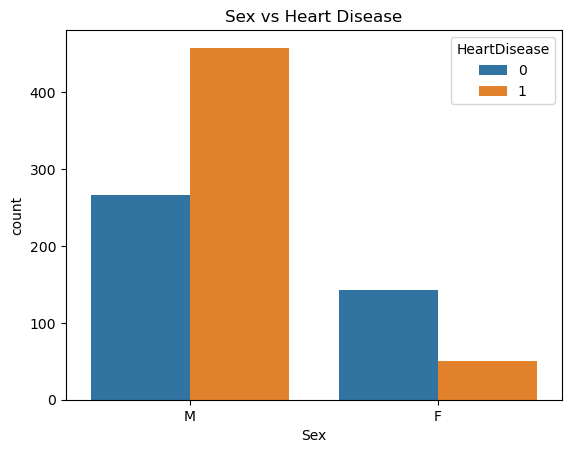

In [46]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("Sex vs Heart Disease")
plt.show()

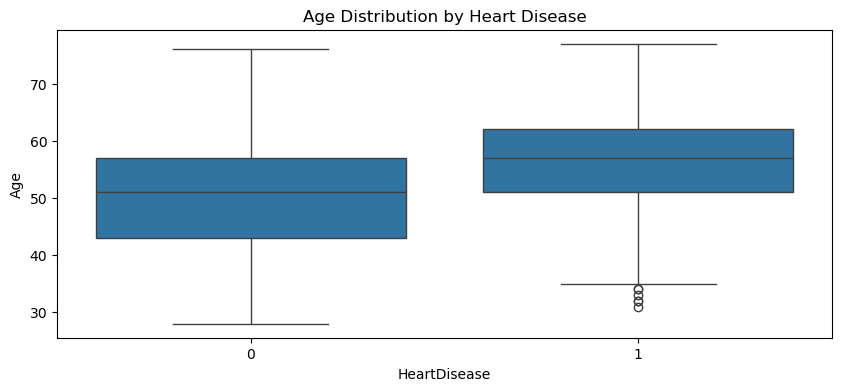

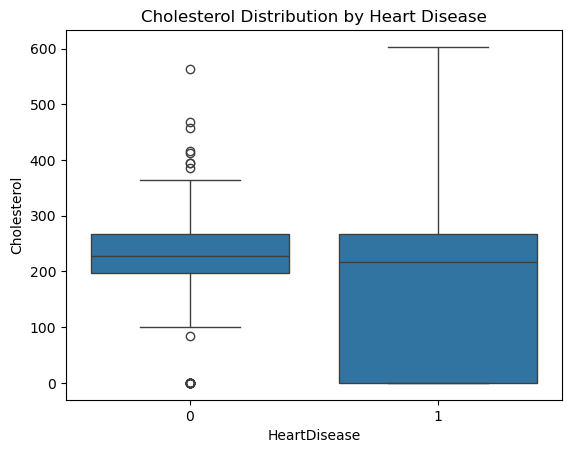

In [47]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="HeartDisease", y="Age")
plt.title("Age Distribution by Heart Disease")
plt.show()

sns.boxplot(data=df, x="HeartDisease", y="Cholesterol")
plt.title("Cholesterol Distribution by Heart Disease")
plt.show()
